# Elkan's theoretical threshold

I want to compare if the experimental thresholds that we obtain when looking for the best metric value are close to Elkan's threoretical threshold.

In many cases, they should, because I'll use logistic regression, which should often (but not always) return calibrated probabilities. If the model's probabilities are calibrateed, then there is a way to determine a threshold value that makes the classifier make cost-sensitive decisions.

Here, I'll use class ratio as the cost, assuming that both classes have equal costs.

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import balanced_accuracy_score

from functions.data import DATASETS_FOR_ANALYSIS as datasets, load_dataset

In [3]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="The total space of parameters")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## Threshold optimisation experiment

For each dataset we load a logistic regression (`logit`) and compare two thresholds:

1. **Bootstrap threshold** – for each of `N_BOOTSTRAP` samples drawn with replacement from the test set, find the threshold that maximises balanced accuracy; report mean ± std across bootstrap iterations.
2. **Theoretical threshold** – derived from the cost matrix:

$$p^* = \frac{C(1,0)}{C(1,0) + C(0,1)}$$

where $C(1,0) = 1$ (cost of a false negative) and $C(0,1) = IR = n_{\text{majority}} / n_{\text{minority}}$ (cost of a false positive, set equal to the imbalance ratio).

In [4]:
RNG = np.random.default_rng(0)

def bootstrap_threshold_ba(y_true, y_proba):
    """Return mean and std of the BA-optimal threshold across bootstrap samples."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    
    n_bootstrap = int(0.6 * len(y_true))
    
    thresholds = []

    for _ in range(3):
        idx = RNG.choice(len(y_true), size=n_bootstrap, replace=True)
        yt, yp = y_true[idx], y_proba[idx]

        candidates = np.unique(yp)
        scores = [
            balanced_accuracy_score(yt, (yp >= t).astype(int))
            for t in candidates
        ]
        thresholds.append(candidates[int(np.argmax(scores))])

    arr = np.array(thresholds)
    return arr.mean(), arr.std()


def theoretical_threshold(y_train):
    """p* = C(1,0) / (C(1,0) + C(0,1)) with C(0,1) = IR."""
    n_majority = (y_train == 0).sum()
    n_minority = (y_train == 1).sum()
    IR = n_majority / n_minority
    c_fn = 1
    c_fp = IR
    return c_fn / (c_fn + c_fp), IR

In [5]:
BASIC_DIR = Path('../models/basic')

records = []

for dataset in datasets:
    _, X_test, y_train, y_test = load_dataset(dataset)

    thresh_theory, IR = theoretical_threshold(y_train)

    path = BASIC_DIR / f'{dataset}_logit.pkl'
    search = joblib.load(path)
    y_proba = search.best_estimator_.predict_proba(X_test)[:, 1]

    thresh_mean, thresh_std = bootstrap_threshold_ba(y_test, y_proba)

    records.append({
        'dataset': dataset,
        'IR': round(IR, 4),
        'thresh_theoretical': round(thresh_theory, 4),
        'thresh_bootstrap_mean': round(thresh_mean, 4),
        'thresh_bootstrap_std': round(thresh_std, 4),
    })

results = pd.DataFrame(records).set_index('dataset')
results

,IR,thresh_theoretical,thresh_bootstrap_mean,thresh_bootstrap_std
dataset,,,,
abalone_19,138.1905,0.0072,0.0074,0.0005
car_eval_4,23.6735,0.0405,0.3079,0.0168
coil_2000,15.5663,0.0604,0.0661,0.0067
ecoli,8.0385,0.1106,0.2575,0.0715
isolet,11.6907,0.0788,0.2165,0.0900
letter_img,25.7686,0.0374,0.0479,0.0236
libras_move,14.7500,0.0635,0.1414,0.0078
mammography,41.7760,0.0234,0.0622,0.0070
oil,22.3929,0.0427,0.0681,0.0054


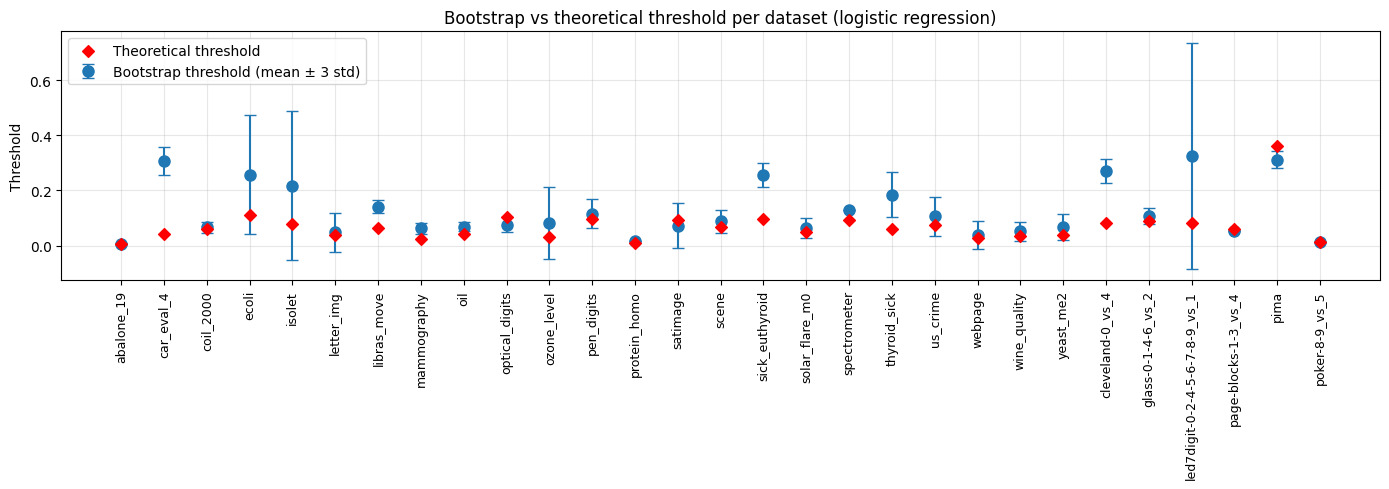

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(results))

ax.errorbar(
    x=x,
    y=results['thresh_bootstrap_mean'],
    yerr=3 * results['thresh_bootstrap_std'],
    fmt='o',
    capsize=4,
    markersize=8,
    label='Bootstrap threshold (mean ± 3 std)',
)

ax.scatter(
    x=x,
    y=results['thresh_theoretical'],
    marker='D',
    color='red',
    zorder=5,
    label='Theoretical threshold',
)

ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=90, fontsize=9)
ax.set_ylabel('Threshold')
ax.set_title('Bootstrap vs theoretical threshold per dataset (logistic regression)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In most cases the theoretical threshold is within the error of the empirical threshold. 

**Important**: the theoretical threshold is reliable if the model probabilities are calibrated and the model also explains well the data pattern. That means that, if we fit a logistic regression to data that is not linear on the log-odds, then the model does not explain the data, and the probabilities may not be calibrated, hence the theoretical threshold does not hold. 

A second challenge is that with small datasets, faithfully assessing calibration with calibration curves is difficult because we have few datapoints particularly of the positive class, so we can't estimate true likelihood with certainty.